# Profiling

This series of notebooks helps data scientists to forecast multiple time series by building models based on the time-series profiling, i.e identifying similar consumption profiles and building a specific model for each cluster. 

Clustering profile of time series data helps in defining the best fitting model by understanding in terms of choice of regressors (calendar variables or temperatures), forecasting algorithm (ARIMA vs Exponential smoothing) and train set (one year or just few days of data). 

The steps to clustering time series are the following:
1. Prepare data by understand the structure of the data (cross-sectional vs panel data), build a full time sequence and treating missing values
2. Indentifying intermittent time series vs smooth time series, by following an **enhanced** classification based on the Syntetos–Boylan–Croston (SBC) use of Coefficient of Variation (CV^2), Average Demand Interval (ADI) and Standard Deviation Demand Interval (SDDI) indicators
   1. Smooth, if ADI<1.32, CV^2<0.49
   2. Intermittent, if ADI>=1.32, CV^2<0.49
   3. Erratic, if ADI<1.32, CV^2>=0.49
   4. Lumpy, if ADI>=1.32, CV^2>=0.49
   5. Unforecastable time, if SDDI >= SDDI threshold, CV^2<0.49
   6. Unforecastable quantity, if SDDI >= SDDI threshold, CV^2>=0.49
3. Clustering with K-Means those time-series identified as **smooth**

In this notebook you will follow step 2 on profiling time series, in particular how to identify regular time series with respect to intermittent, erratic, lumpy unforecastable in terms of time and unforecastable in terms of quantity.

# Summary of tasks

Your task in this notebook is to identify consumption patterns that are similar to each other in order to assign the optimal model to forecast their demand​. 

Your **goal** is to identify the series that is classified as “intermittent” with respect to those “regular or smooth”​ and **then** proceed to perform a k-means cluster analysis only on the latter. 

The **expected output** is to label each time series as spikes, lumpy, erratic, unforecastable in terms of time volatility, unforecastable in terms of quantity volatility, constant, constant at zero with respect to regular.

Follow the instructions: 

## What are intermittent time series:​
Intermittent time series or demand comes about when a product or a time series experiences several periods of zero demand. Often in these situation, when demand occurs it is small, and sometimes highly variable in size​

#### How to identify intermittent time series:​
Compute the following indicators such as
1. ​Average Inter-demand Interval (ADI), this parameter is period based which is calculated as average interval time between two demand occurrences​
2. Coefficient of Variation Squared (CV2), this statistical parameter is calculated as standard deviation of the *For correspondence demand divided by the average demand for non-zero demand periods. The squared coefficient of variation represents variability of demand size.​
3. Standard Deviation of Inter-demand Interval (SDDI) ​

Based on their values, it is possible to identify intermittent time series as:
  - spikes
  - lumpy
  - erratic
  - unforecastable in terms of time volatility
  - unforecastable in terms of quantity volatility
  - constant
  - constant at zero
  - regular or smooth time series ​

#### Intermittent indicators parameters
Intermittent indicators parameters vary depending on the type of time series (i.e. data generation process of the time series) such as energy consumption in KWh or insurance claims in USD, therefore intermittent indicators must be set every time depending on the type of time series and their validation is done looking at time series charts resulting from the profiling Notebook.

Intermittent indicators are the following:
  - **thres_cv2_constant** defines the threshold value to set constant time series with respect to a constant at zero time series
  - **thres_cv2** defines the threshold value between low CV2 and high CV2
  - **thres_adi** defines the threshold value between low ADI and high ADI
  - **thres_sddi** defines the threshold value between low SDDI and high SDDI
  - **min_time_cons** defines the threshold value of minimum time between two demand entries (on with respect to off demand)

#### How to identify thresholds for intermittent indicators parameters:​
Parameters for retail demand, units, montly data.
  - thres_cv2_constant = 0.0032
  - thres_cv2 = 0.49
  - thres_adi = 1.32
  - thres_sddi = 8.995
  - min_time_cons = 6
  
Parameters for electricity consumption in KWh, daily data.
  - thres_cv2_constant = 0.06
  - thres_cv2 = 2
  - thres_adi = 3
  - thres_sddi = 6.2
  - min_time_cons = 2

Parameters for insurance claims data in USD, daily data. Claims from work accidents in mining industry.
  - thres_cv2_constant = 0.01
  - thres_cv2 = 0.2
  - thres_adi = 1.2
  - thres_sddi = 6.0
  - min_time_cons = 25

##### What if you are working with data that are not related to retail demand in units, energy consumption in KwH or insurance data in USD?
You need to setup new intermittent indicators. To do so, run the notebook and iteratively set new parameters for thres_cv2_constant, thres_cv2, thres_adi, thres_sddi, min_time_cons and look if the resulting classification makes sense. 



## 1. Import Required Libraries

In [1]:
# Core libraries for Fabric
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from pathlib import Path
import os

print("✅ Core libraries imported successfully")

✅ Core libraries imported successfully


## 2. Define Intermittent Classification Functions

These functions compute the SBC indicators and classify time series based on thresholds.

In [2]:
class Intermittent:
    @staticmethod
    def cv2(array, highest=0.05, lowest=0.05):
        '''Computes coefficient of variation squared with winsorization'''
        winsorized_array = winsorize(array, (highest, lowest))
        cv2 = (np.std(winsorized_array) / np.mean(winsorized_array)) ** 2
        return cv2
    
    @staticmethod
    def adi(array, highest=0.05, lowest=0.05):
        '''Computes average demand interval with winsorization'''
        winsorized_array = winsorize(array, (highest, lowest))
        adi = np.mean(winsorized_array)
        return adi
    
    @staticmethod
    def sddi(array, highest=0.05, lowest=0.05):
        '''Computes standard deviation of demand interval with winsorization'''
        winsorized_array = winsorize(array, (highest, lowest))
        sddi = np.std(winsorized_array)
        return sddi
    
    @staticmethod
    def compute_indicator_values(vect, threshold, perc, quant, highest, lowest):
        '''Computes indicator values for intermittent classification'''
        if isinstance(vect, np.ndarray) == False:
            try:
                vect = np.array(vect)
            except:
                raise Exception("identify_intermittent: input vect is not numeric and could not be converted")
        
        if threshold == '':
            threshold = vect[0]
            vect = vect[1:len(vect)]
        
        # Removing nan
        vect = vect[~np.isnan(vect)]
        vect = vect.astype(float)

        # Create low demand list names
        list_low_demand = ["zero", "perc_threshold"]
        for ind in ["floor_perc_quant_", "perc_quant_"]:
            list_low_demand.append(ind + str(quant).replace('0.', ''))

        for LD in list_low_demand:
            if LD == "zero":
                low_demand = 0
            elif LD == "perc_threshold":
                low_demand = perc * threshold
            elif LD == "floor_perc_quant_" + str(quant).replace('0.', ''):
                low_demand = max([0.250, 0.001 * np.quantile(vect, quant)])
            elif LD == "perc_quant_" + str(quant).replace('0.', ''):
                low_demand = perc * np.quantile(vect, quant)
            
            nzd = vect[vect > low_demand]
            k = len(nzd)
            
            if (sum(vect[vect > low_demand]) >= 2) & (k > 1):
                x = np.append([nzd[0]], [nzd[1:k] - nzd[0:(k-1)]])
                
                cv2 = Intermittent.cv2(nzd, highest, lowest)
                adi = Intermittent.adi(x, highest, lowest)
                sddi = Intermittent.sddi(x, highest, lowest)
            else:
                cv2 = np.nan
                adi = np.nan
                sddi = np.nan

            res = pd.DataFrame.from_dict({
                'type': [LD], 'k': [k], 'low_demand': [low_demand],
                'cv2': [cv2], 'adi': [adi], 'sddi': [sddi]
            })
        
        return res
    
    @staticmethod
    def classify_intermittent(df, type_val, thres_cv2_constant, thres_cv2, thres_adi, thres_sddi, min_time_cons):
        '''Classifies intermittent time series based on indicator values'''
        score_no_nan = df.dropna()

        # Regular
        mask_regular = ((score_no_nan['type'] == type_val) &
                       (score_no_nan['k'] > min_time_cons) &
                       (score_no_nan['cv2'] >= thres_cv2_constant) &
                       (score_no_nan['cv2'] < thres_cv2) &
                       (score_no_nan['cv2'] < thres_adi) &
                       (score_no_nan['cv2'] < thres_sddi))
        df_regular = score_no_nan.loc[mask_regular].copy()
        df_regular['profile'] = 'regular'
        print(f'classify_intermittent: regular ids {len(df_regular)}')

        # Constant at zero
        mask_constant_zero = ((score_no_nan['type'] == type_val) &
                             (score_no_nan['k'] <= min_time_cons))
        df_constant_zero = score_no_nan.loc[mask_constant_zero].copy()
        df_constant_zero['profile'] = 'constant_zero'
        print(f'classify_intermittent: constant_zero ids {len(df_constant_zero)}')

        # Constant
        mask_constant = ((score_no_nan['type'] == type_val) &
                        (score_no_nan['k'] > min_time_cons) &
                        (score_no_nan['cv2'] < thres_cv2_constant) &
                        (score_no_nan['cv2'] < thres_adi) &
                        (score_no_nan['cv2'] < thres_sddi))
        df_constant = score_no_nan.loc[mask_constant].copy()
        df_constant['profile'] = 'constant'
        print(f'classify_intermittent: constant ids {len(df_constant)}')

        # Spikes
        mask_spikes = ((score_no_nan['type'] == type_val) &
                      (score_no_nan['k'] > min_time_cons) &
                      (score_no_nan['cv2'] < thres_cv2) &
                      (score_no_nan['cv2'] >= thres_adi) &
                      (score_no_nan['cv2'] < thres_sddi))
        df_spikes = score_no_nan.loc[mask_spikes].copy()
        df_spikes['profile'] = 'spikes'
        print(f'classify_intermittent: spikes ids {len(df_spikes)}')

        # Lumpy
        mask_lumpy = ((score_no_nan['type'] == type_val) &
                     (score_no_nan['k'] > min_time_cons) &
                     (score_no_nan['cv2'] >= thres_cv2) &
                     (score_no_nan['cv2'] >= thres_adi) &
                     (score_no_nan['cv2'] < thres_sddi))
        df_lumpy = score_no_nan.loc[mask_lumpy].copy()
        df_lumpy['profile'] = 'lumpy'
        print(f'classify_intermittent: lumpy ids {len(df_lumpy)}')

        # Erratic
        mask_erratic = ((score_no_nan['type'] == type_val) &
                       (score_no_nan['k'] > min_time_cons) &
                       (score_no_nan['cv2'] >= thres_cv2) &
                       (score_no_nan['cv2'] < thres_adi) &
                       (score_no_nan['cv2'] < thres_sddi))
        df_erratic = score_no_nan.loc[mask_erratic].copy()
        df_erratic['profile'] = 'erratic'
        print(f'classify_intermittent: erratic ids {len(df_erratic)}')

        # Unforecastable time
        mask_unforecastable_time = ((score_no_nan['type'] == type_val) &
                                   (score_no_nan['k'] > min_time_cons) &
                                   (score_no_nan['cv2'] < thres_cv2) &
                                   (score_no_nan['cv2'] >= thres_sddi))
        df_unforecastable_time = score_no_nan.loc[mask_unforecastable_time].copy()
        df_unforecastable_time['profile'] = 'unforecastable_time'
        print(f'classify_intermittent: unforecastable_time ids {len(df_unforecastable_time)}')

        # Unforecastable quantity
        mask_unforecastable_quantity = ((score_no_nan['type'] == type_val) &
                                       (score_no_nan['k'] > min_time_cons) &
                                       (score_no_nan['cv2'] >= thres_cv2) &
                                       (score_no_nan['cv2'] >= thres_sddi))
        df_unforecastable_quantity = score_no_nan.loc[mask_unforecastable_quantity].copy()
        df_unforecastable_quantity['profile'] = 'unforecastable_quantity'
        print(f'classify_intermittent: unforecastable_quantity ids {len(df_unforecastable_quantity)}')

        # Combine all profiles
        df_profiling = pd.concat([
            df_regular, df_constant_zero, df_constant, df_spikes,
            df_lumpy, df_erratic, df_unforecastable_time, df_unforecastable_quantity
        ], axis=0)
        
        return df_profiling

print("✅ Intermittent class defined successfully")

✅ Intermittent class defined successfully


## 3. Configuration Parameters

Set the time series and intermittent classification parameters.

In [14]:
# Time series parameters
id = 'product_name'
unique_id = 'STORE_LOCATION_ID'
date_var = 'WEEK_START_DT'
list_unique_id = [unique_id, date_var]
y = 'TOTAL_NET_SALES'
date_var = 'WEEK_START_DT'
date_format = '%Y-%m-%d'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"
INPUT_TABLE = "df_final"
OUTPUT_TABLE = "df_profiling"
LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

root_path = Path.cwd().parent

# Winsorizing parameters
highest = 0.05
lowest = 0.05

# Identifying intermittent time series parameters
threshold = 250
perc = 0.01
quant = 0.999

# CUSTOMIZED: Thresholds calibrated for weekly revenue data ($150K–$1.6M range)
# Original retail monthly (units): cv2_const=0.0032, cv2=0.49, adi=1.32, sddi=8.995, min_time=6
# Adjusted for weekly supermarket net sales (USD):
thres_cv2_constant = 0.003
thres_cv2 = 0.03          # Stricter — may flag highest-variability stores as erratic
thres_adi = 10000          # All stores have ADI < 10,000
thres_sddi = 80000         # All stores have SDDI < 80,000
min_time_cons = 10         # Weekly data, 103 obs per series

print("✅ Configuration parameters set")
print(f"   - Target variable: {y}")
print(f"   - Date variable: {date_var}")
print(f"   - Unique ID: {unique_id}")
print(f"   - Domain: Retail demand (weekly revenue USD)")
print(f"   - Thresholds: cv2={thres_cv2}, adi={thres_adi}, sddi={thres_sddi}, min_time={min_time_cons}")

✅ Configuration parameters set
   - Target variable: TOTAL_NET_SALES
   - Date variable: WEEK_START_DT
   - Unique ID: STORE_LOCATION_ID
   - Domain: Retail demand (weekly revenue USD)
   - Thresholds: cv2=0.03, adi=10000, sddi=80000, min_time=10


## 4. Load Data from Lakehouse

Load the prepared data from notebook 01 (DataPreparation).

In [5]:
# Read from Lakehouse table using Spark, then convert to Pandas
try:
    df_spark = spark.table(f"{LAKEHOUSE_NAME}.{INPUT_TABLE}")
    df = df_spark.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{INPUT_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent
    df = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{INPUT_TABLE}.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df)} rows")
print(df.head())

❌ Error loading data from ts_forecasting.df_final, loading from local file instead.
✅ Loaded 5150 rows
   STORE_LOCATION_ID WEEK_START_DT  TOTAL_NET_SALES  STORE_SELLING_AREA_SQFT  \
0                  1    2023-04-03    522814.849132                    32653   
1                  1    2023-04-10    620024.491881                    32653   
2                  1    2023-04-17    623209.751040                    32653   
3                  1    2023-04-24    641359.169727                    32653   
4                  1    2023-05-01    615285.571504                    32653   

   NEARBY_COMPETITOR_STORE_COUNT  COMPETITOR_PREMIUM_A_PRESENT  \
0                              2                             0   
1                              2                             0   
2                              2                             0   
3                              2                             0   
4                              2                             0   

   COMPETITOR_DISCO

In [6]:
# Parse date column
df[date_var] = pd.to_datetime(df[date_var])

print(f"✅ Data loaded from lakehouse table 'ts_forecasting.df_final'")
print(f"   Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

✅ Data loaded from lakehouse table 'ts_forecasting.df_final'
   Rows: 5150, Columns: 95


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Check Missing Values

In [7]:
df_missing = df.loc[df[y].isnull(),]
print(f"Number of missing values in '{y}': {len(df_missing)}, out of {len(df)} total records.")
print(f"Percentage: {len(df_missing)/len(df)*100:.2f}%")

Number of missing values in 'TOTAL_NET_SALES': 0, out of 5150 total records.
Percentage: 0.00%


## 6. Define Working Dataframe

Substitute null values with 0 to represent no demand/consumption.

In [8]:
df[y] = df[y].fillna(0)

print('Unique IDs available:', list(df[unique_id].unique())[:5], '...')
print('Number of unique IDs:', len(list(df[unique_id].unique())))

Unique IDs available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] ...
Number of unique IDs: 50


## 7. ✅ CHECK POINT with the data scientist: visualize demand over time

Show the data scientist the plot to make sure you have correctly identified the `unique_id`.
If the plot looks wrong (e.g., unexpected grouping or missing series), revisit your `unique_id` definition and the date parsing logic.

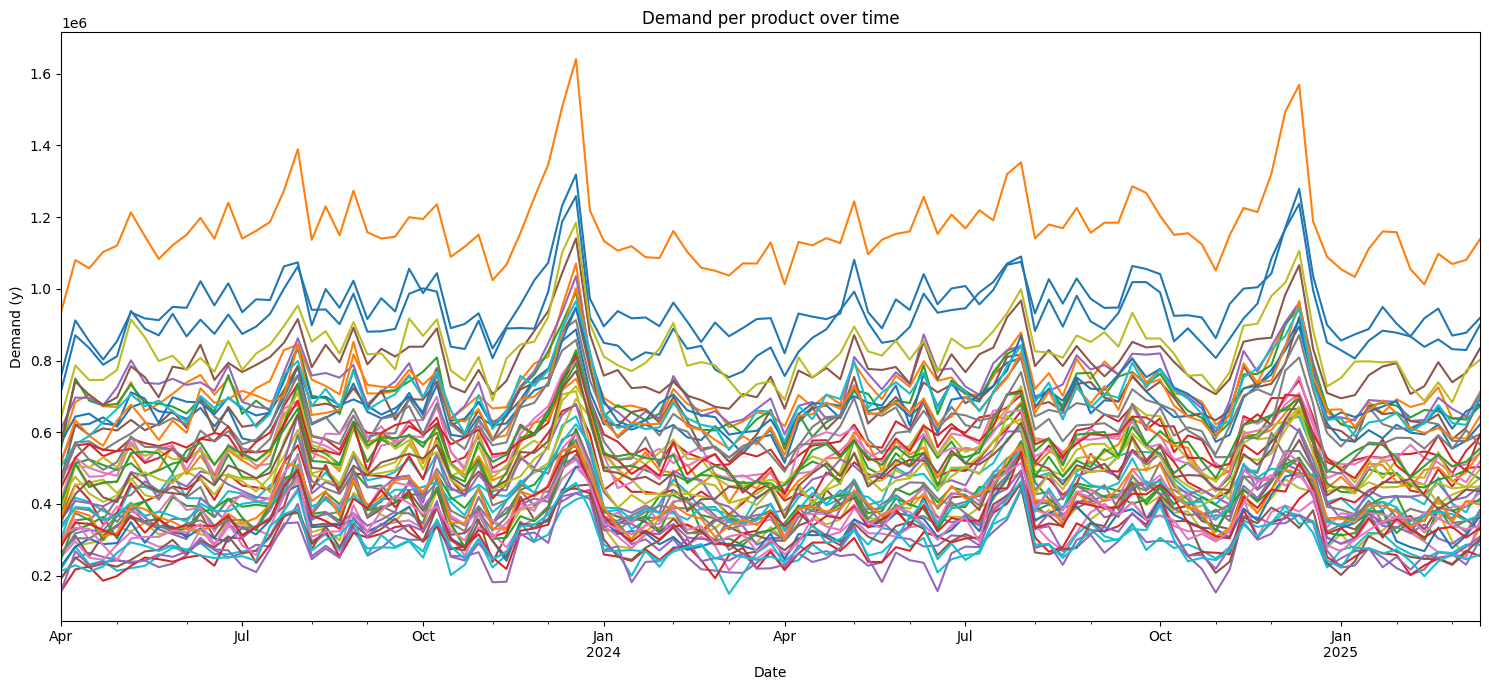

✅ Chart saved to: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent\data\supermarket_net_sales\charts\demand_per_product_over_time.png


In [10]:
# Create charts directory if it doesn't exist
charts_dir = os.path.join(root_path, "data", LOCAL_FOLDER, "charts")
os.makedirs(charts_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(15, 7))
df.groupby([unique_id, date_var])[y].apply(np.mean).reset_index().pivot(
    index=date_var, columns=unique_id, values=y
).plot(ax=ax, legend=False)
ax.set_title('Demand per product over time')
ax.set_ylabel('Demand (y)')
ax.set_xlabel('Date')
plt.tight_layout()

chart_name = f"demand_per_product_over_time"
chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
fig.savefig(chart_path, dpi=900, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to: {chart_path}")

## 8. Compute Intermittent Indicators

Calculate CV², ADI, and SDDI for each time series.

In [11]:
# Compute indicators grouped by unique_id
df_grouped = df.groupby(unique_id)[y].apply(
    lambda y_vals: Intermittent.compute_indicator_values(
        np.array(y_vals), threshold, perc, quant, highest, lowest
    )
)

print("✅ Intermittent indicators computed")
df_grouped.head()

✅ Intermittent indicators computed


,,type,k,low_demand,cv2,adi,sddi
STORE_LOCATION_ID,,,,,,,
1,0,perc_quant_999,103,8940.914706,0.008781,2902.041137,55729.031602
2,0,perc_quant_999,103,10579.725185,0.007291,4899.035184,60100.748047
3,0,perc_quant_999,103,9874.136855,0.008653,2205.769570,65536.257704
4,0,perc_quant_999,103,8020.743506,0.009046,2260.903782,52457.242364
5,0,perc_quant_999,103,10278.655113,0.009100,1648.101756,65918.562441


In [12]:
# Create scoring dataframe
df_scoring = df_grouped.reset_index()[[unique_id, 'type', 'k', 'low_demand', 'cv2', 'adi', 'sddi']].sort_values(by=[unique_id])

print("✅ df_scoring created")
print(f"   Rows: {len(df_scoring)}, Columns: {len(df_scoring.columns)}")
df_scoring.head()

✅ df_scoring created
   Rows: 50, Columns: 7


,STORE_LOCATION_ID,type,k,low_demand,cv2,adi,sddi
0,1,perc_quant_999,103,8940.914706,0.008781,2902.041137,55729.031602
1,2,perc_quant_999,103,10579.725185,0.007291,4899.035184,60100.748047
2,3,perc_quant_999,103,9874.136855,0.008653,2205.769570,65536.257704
3,4,perc_quant_999,103,8020.743506,0.009046,2260.903782,52457.242364
4,5,perc_quant_999,103,10278.655113,0.009100,1648.101756,65918.562441


## 9. Indicator Statistics

In [13]:
# Exclude NaN indicators
df_scoring_no_nan = df_scoring.dropna()
list_nan = list(set(df_scoring[unique_id]) - set(df_scoring_no_nan[unique_id]))
print('List of NaN ids:', list_nan if list_nan else 'None')

# Show indicator statistics
list_indicators = ['cv2', 'adi', 'sddi']
for ind in list_indicators:
    print(f"\n{ind.upper()} statistics:")
    print(f"  mean: {round(df_scoring[ind].mean(), 3)}")
    print(f"  max: {round(df_scoring[ind].max(), 3)}")
    print(f"  min: {round(df_scoring[ind].min(), 3)}")
    print(f"  median: {round(df_scoring[ind].median(), 3)}")

List of NaN ids: None

CV2 statistics:
  mean: 0.016
  max: 0.037
  min: 0.005
  median: 0.015

ADI statistics:
  mean: 3264.583
  max: 8901.893
  min: 1081.069
  median: 2904.937

SDDI statistics:
  mean: 54079.376
  max: 75903.104
  min: 40615.123
  median: 53255.522


## 10. ✅ CHECK POINT with the data scientist: classify intermittent time series

In this stage, once you have computed for each `unique_id` the values of `cv2`, `adi`, `sddi` indicators, you can proceed to classify time series based on indicator thresholds.

⚠️ Remember that thresholds vary with respect to the type of data you are using.

In [15]:
# Get the type value
type_val = df_scoring_no_nan['type'].unique()[0]
print(f'Type: {type_val}')

Type: perc_quant_999


In [16]:
# Classify time series
df_profiling = Intermittent.classify_intermittent(
    df_scoring_no_nan, 
    type_val, 
    thres_cv2_constant, 
    thres_cv2, 
    thres_adi, 
    thres_sddi, 
    min_time_cons
)

print(f"\n✅ Classification completed")
print(f"   Total classified: {len(df_profiling)}")
df_profiling.head()

classify_intermittent: regular ids 48
classify_intermittent: constant_zero ids 0
classify_intermittent: constant ids 0
classify_intermittent: spikes ids 0
classify_intermittent: lumpy ids 0
classify_intermittent: erratic ids 2
classify_intermittent: unforecastable_time ids 0
classify_intermittent: unforecastable_quantity ids 0

✅ Classification completed
   Total classified: 50


,STORE_LOCATION_ID,type,k,low_demand,cv2,adi,sddi,profile
0,1,perc_quant_999,103,8940.914706,0.008781,2902.041137,55729.031602,regular
1,2,perc_quant_999,103,10579.725185,0.007291,4899.035184,60100.748047,regular
2,3,perc_quant_999,103,9874.136855,0.008653,2205.769570,65536.257704,regular
3,4,perc_quant_999,103,8020.743506,0.009046,2260.903782,52457.242364,regular
4,5,perc_quant_999,103,10278.655113,0.009100,1648.101756,65918.562441,regular


## 11. ✅ CHECK POINT with the data scientist: review profile counts and examples

If the feedback from the data scientist is negative, you need to adjust thresholds. Follow these steps:

1. Choose randomly 3 examples for each profile
2. Show the examples and the values of ADI and CV2
3. Ask if the profile is correct
4. If not, ask if average demand interval should be increased or decreased: act accordingly by increasing or decreasing ADI, CV2 and also SDDI with a 20% change
5. Repeat steps 2 to 4 until the profile is correct
6. Write down the threshold for each use case; you are going to use them again with the same type of data (e.g. electricity demand, insurance claims, etc.)

Alternatively, you can also provide the data scientist with a playground notebook and the data so that they can provide you with the correct thresholds.

⚠️ This is a lengthy process but it is going to be beneficial for performance!

In [17]:
list_of_profiles = ['regular', 'constant_zero', 'constant', 'spikes',
                    'lumpy', 'erratic', 'unforecastable_time', 'unforecastable_quantity']

dict_profiling = {}
print("📊 Profile Summary:")
print("-" * 50)
for c in list_of_profiles:
    dict_profiling[c] = list(
        df_profiling.loc[df_profiling.profile == c, unique_id].unique())
    count = len(dict_profiling[c])
    print(f"  {c:25s}: {count:3d} series")
    if count > 0 and count <= 5:
        print(f"    IDs: {dict_profiling[c]}")
    elif count > 5:
        print(f"    Sample IDs: {dict_profiling[c][:3]}...")
print("-" * 50)
print(f"  {'TOTAL':25s}: {len(df_profiling):3d} series")

📊 Profile Summary:
--------------------------------------------------
  regular                  :  48 series
    Sample IDs: [np.int64(1), np.int64(2), np.int64(3)]...
  constant_zero            :   0 series
  constant                 :   0 series
  spikes                   :   0 series
  lumpy                    :   0 series
  erratic                  :   2 series
    IDs: [np.int64(24), np.int64(45)]
  unforecastable_time      :   0 series
  unforecastable_quantity  :   0 series
--------------------------------------------------
  TOTAL                    :  50 series



Profile 'regular': plotting 3 example series: [np.int64(42), np.int64(8), np.int64(2)]


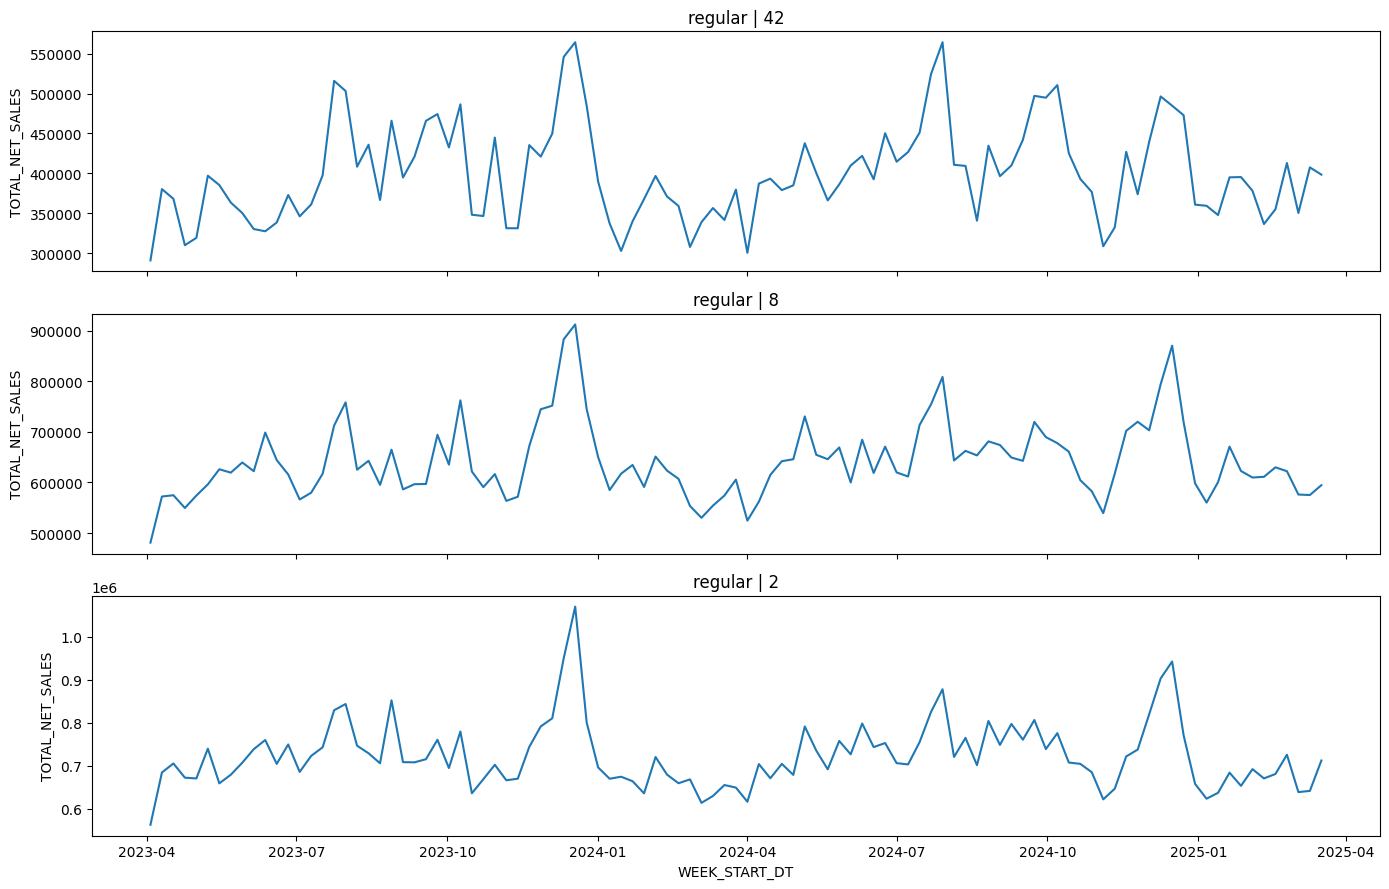

✅ Chart saved to: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent\data\supermarket_net_sales\charts\cluster_examples_regular.png

Profile 'constant_zero': no series

Profile 'constant': no series

Profile 'spikes': no series

Profile 'lumpy': no series

Profile 'erratic': plotting 2 example series: [np.int64(24), np.int64(45)]


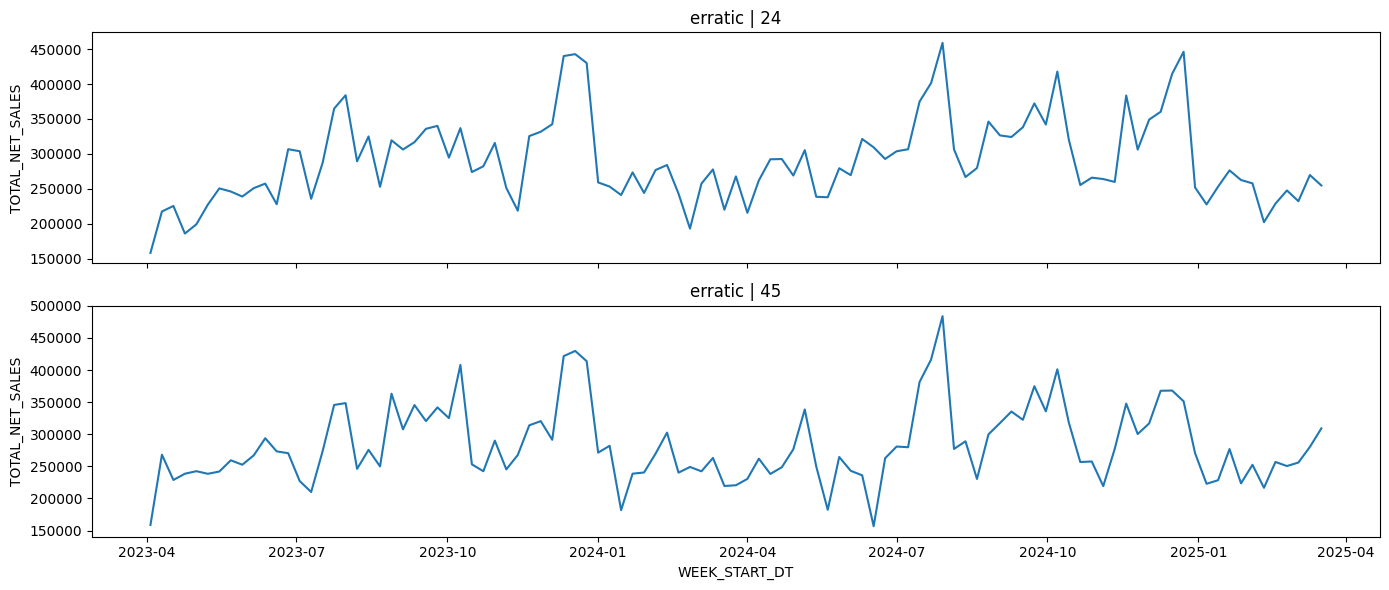

✅ Chart saved to: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent\data\supermarket_net_sales\charts\cluster_examples_erratic.png

Profile 'unforecastable_time': no series

Profile 'unforecastable_quantity': no series


In [18]:
import random

# Plot a small sample of series per profile for visual review and save each figure correctly

random.seed(42)
examples_per_profile = 3

for profile_name in list_of_profiles:
    ids = dict_profiling.get(profile_name, [])
    if not ids:
        print(f"\nProfile '{profile_name}': no series")
        continue

    sample_ids = ids if len(ids) <= examples_per_profile else random.sample(ids, examples_per_profile)
    print(f"\nProfile '{profile_name}': plotting {len(sample_ids)} example series: {sample_ids}")

    fig, axes = plt.subplots(
        nrows=len(sample_ids),
        ncols=1,
        figsize=(14, 3 * len(sample_ids)),
        sharex=True
    )

    if len(sample_ids) == 1:
        axes = [axes]

    for ax, uid in zip(axes, sample_ids):
        ts = df.loc[df[unique_id] == uid, [date_var, y]].sort_values(date_var)
        ax.plot(ts[date_var], ts[y])
        ax.set_title(f"{profile_name} | {uid}")
        ax.set_ylabel(y)

    axes[-1].set_xlabel(date_var)
    plt.tight_layout()

    chart_name = f"cluster_examples_{profile_name}"
    chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
    fig.savefig(chart_path, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close(fig)

    print(f"✅ Chart saved to: {chart_path}")


Profile 'regular': plotting 3 example series: [np.int64(41), np.int64(8), np.int64(2)]


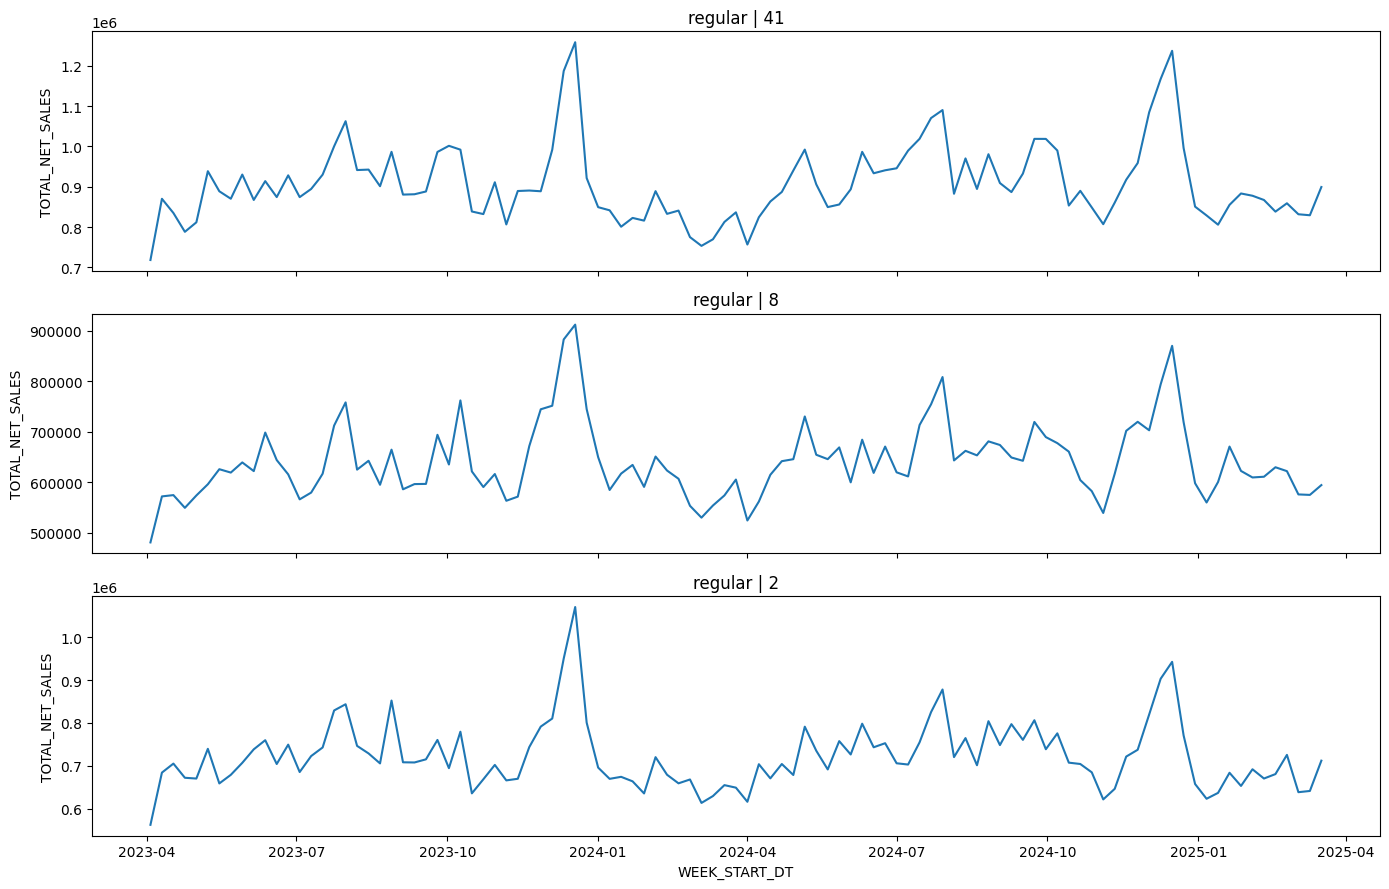


Profile 'constant_zero': no series

Profile 'constant': no series

Profile 'spikes': no series

Profile 'lumpy': no series

Profile 'erratic': no series

Profile 'unforecastable_time': no series

Profile 'unforecastable_quantity': no series


<Figure size 640x480 with 0 Axes>

In [49]:
# Plot a small sample of series per profile for visual review (inline only; no file outputs)
import random

random.seed(42)
examples_per_profile = 3

for profile_name in list_of_profiles:
    ids = dict_profiling.get(profile_name, [])
    if not ids:
        print(f"\nProfile '{profile_name}': no series")
        continue
    sample_ids = ids if len(ids) <= examples_per_profile else random.sample(ids, examples_per_profile)
    print(f"\nProfile '{profile_name}': plotting {len(sample_ids)} example series: {sample_ids}")
    
    fig, axes = plt.subplots(nrows=len(sample_ids), ncols=1, figsize=(14, 3 * len(sample_ids)), sharex=True)
    if len(sample_ids) == 1:
        axes = [axes]
    
    for ax, uid in zip(axes, sample_ids):
        ts = df.loc[df[unique_id] == uid, [date_var, y]].sort_values(date_var)
        ax.plot(ts[date_var], ts[y])
        ax.set_title(f"{profile_name} | {uid}")
        ax.set_ylabel(y)
    axes[-1].set_xlabel(date_var)
    plt.tight_layout()
    plt.show()
    chart_name = f"cluster_examples_{profile_name}"
chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
plt.savefig(chart_path, dpi=900, bbox_inches='tight')

⚠️ Save also the type of data you are profiling and the ADI, CV2 and SDDI thresholds.

## 12. Save Results to Lakehouse

In [19]:
# ============================================================
# SAVE TO LAKEHOUSE TABLE
# ============================================================
try:
# Convert pandas DataFrame to Spark DataFrame and save as Delta table
    df_profiling_spark = spark.createDataFrame(df_profiling)
    df_profiling_spark.write.mode("overwrite").saveAsTable(f"{LAKEHOUSE_NAME}.{OUTPUT_TABLE}")

    print(f"✅ df_profiling saved to: {LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
except:
    df_profiling.to_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{OUTPUT_TABLE}.parquet")
    print(f"❌ Error saving results to Lakehouse table")
    print("Saving to local file instead.")
    print(f"✅ df_features saved locally at: {root_path}/data/{LOCAL_FOLDER}/{OUTPUT_TABLE}.parquet") 
    
print(f"✅ df_profiling saved to lakehouse table 'ts_forecasting.df_profiling'")
print(f"   Rows: {len(df_profiling)}, Columns: {len(df_profiling.columns)}")
print(f"   Columns: {list(df_profiling.columns)}")

❌ Error saving results to Lakehouse table
Saving to local file instead.
✅ df_features saved locally at: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent/data/supermarket_net_sales/df_profiling.parquet
✅ df_profiling saved to lakehouse table 'ts_forecasting.df_profiling'
   Rows: 50, Columns: 8
   Columns: ['STORE_LOCATION_ID', 'type', 'k', 'low_demand', 'cv2', 'adi', 'sddi', 'profile']


---

## ✅ Migration Complete

**Next Steps:**
1. Run notebook 05 (Clustering) on the `regular` time series identified in this notebook
2. Use the `df_profiling` table for downstream model selection
3. Consider different forecasting strategies for each profile category